# Micro-Project 4 — Deep Learning Regression on Age-Ordered Income Sequences

**Janna Hoyne**
## Constructing a sequence from cross-sectional data

A recurrent network processes a sequence, carrying a hidden state from one step
to the next, so it requires data in which order carries information. The Adult
dataset is a single 1994 cross-section of 32,561 independent records with no time
index.

Age supplies the ordering the dataset otherwise lacks. Aggregating to the share
of people earning above $50K at each age within a demographic group produces a
series measured at regular one-year intervals, and predicting the rate at the
next age from a window of previous ages is a forecasting problem with a
continuous target, which makes it regression.

The ordering is by age rather than by time. These are cross-sectional age profiles rather than cohorts followed
through time: the 60-year-olds and the 30-year-olds are different people observed
in the same year, so age  effects are confounded in every
series. The constraint limits what the forecasts mean without preventing the
sequence from being a real one, and it is treated as a limitation on
interpretation rather than a reason to abandon the approach.

## Hypothesis (H3)

Micro Project 3 found that sex remained predictive of income class after conditioning
on education, hours, occupation, and marital status (odds ratio ≈ 1.25), and that
marital status carried a substantially different coefficient for women than for
men.

> **H3.** The age profile of high-income attainment has enough sequential
> structure that a recurrent network can forecast the next age's rate from the
> preceding window, and it will do so more accurately than a feedforward network
> given the same window flattened, because order carries information.


In [1]:
#!pip install tensorflow
#!pip install tensorboard

In [2]:
import os, warnings, logging

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
warnings.filterwarnings('ignore')
logging.getLogger('tensorflow').setLevel(logging.ERROR)

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

np.random.seed(42)
tf.random.set_seed(42)

# pp style
CREAM, FEMALE, MALE = '#F2EFE8', '#C2185B', '#37474F'
plt.rcParams.update({'figure.facecolor': CREAM, 'axes.facecolor': CREAM,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'font.size': 11})

PATH = next(p for p in ['adult_income.csv', 'adult income.csv']
            if os.path.exists(p))
df = pd.read_csv(PATH)

print("TensorFlow:", tf.__version__)
print("Loaded    :", PATH, df.shape)

TensorFlow: 2.21.0
Loaded    : adult income.csv (32561, 15)


## Prepare

Two grouping variables are needed before the sequences can be built. `edu_band`
collapses the 16 `education-num` levels to five, and `married` collapses marital
status to married-spouse-present versus everything else.

Each group-age cell
has to hold enough people for its rate to be stable, and grouping by occupation
and sex left many cells with fewer than five people. Twenty groups across 51 ages
gives a median cell of 17.

Ages are restricted to 20–70, since the high-income rate is near zero below 20
and the cells thin out sharply above 70.

In [3]:
for col in ['sex', 'marital-status', 'income', 'occupation', 'workclass']:
    df[col] = df[col].astype(str).str.strip()

df['high_income'] = (df['income'] == '>50K').astype(int)

def edu_band(n):
    if n <= 8:  return 'E1_no_hs'
    if n <= 9:  return 'E2_hs'
    if n <= 12: return 'E3_some_col'
    if n <= 13: return 'E4_bachelors'
    return 'E5_advanced'

df['edu_band'] = df['education-num'].apply(edu_band)
df['married']  = np.where(df['marital-status'] == 'Married-civ-spouse',
                          'Mar', 'Unm')

d = df[(df['age'] >= 20) & (df['age'] <= 70)].copy()
print(f"Rows retained: {len(d):,} of {len(df):,}")
print(f"Groups: {d.groupby(['sex','edu_band','married']).ngroups}")

Rows retained: 30,364 of 32,561
Groups: 20


In [4]:
# Aggregate to one rate per (group, age): the share earning >$50K.
g = (d.groupby(['sex', 'edu_band', 'married', 'age'])['high_income']
       .agg(rate='mean', n='size')
       .reset_index()
       .sort_values(['sex', 'edu_band', 'married', 'age']))

# Small cells make the raw rate jumpy, so smooth over a 3-age centred window.
# This is a denoising step on the input series, not a change of target.
g['rate_s'] = (g.groupby(['sex', 'edu_band', 'married'])['rate']
                 .transform(lambda s: s.rolling(3, center=True,
                                                min_periods=1).mean()))

print(f"Series : {g.groupby(['sex','edu_band','married']).ngroups}")
print(f"Cells  : {len(g)}")
print(f"Cell size — median {int(g['n'].median())}, "
      f"min {int(g['n'].min())}, max {int(g['n'].max())}")
print(f"Rate range: {g['rate_s'].min():.3f} to {g['rate_s'].max():.3f}")

Series : 20
Cells  : 971
Cell size — median 17, min 1, max 248
Rate range: 0.000 to 1.000


## Explore

The shape of the age profiles determines whether if it is flat or erratic curves would leave a recurrent model nothing to forecast.

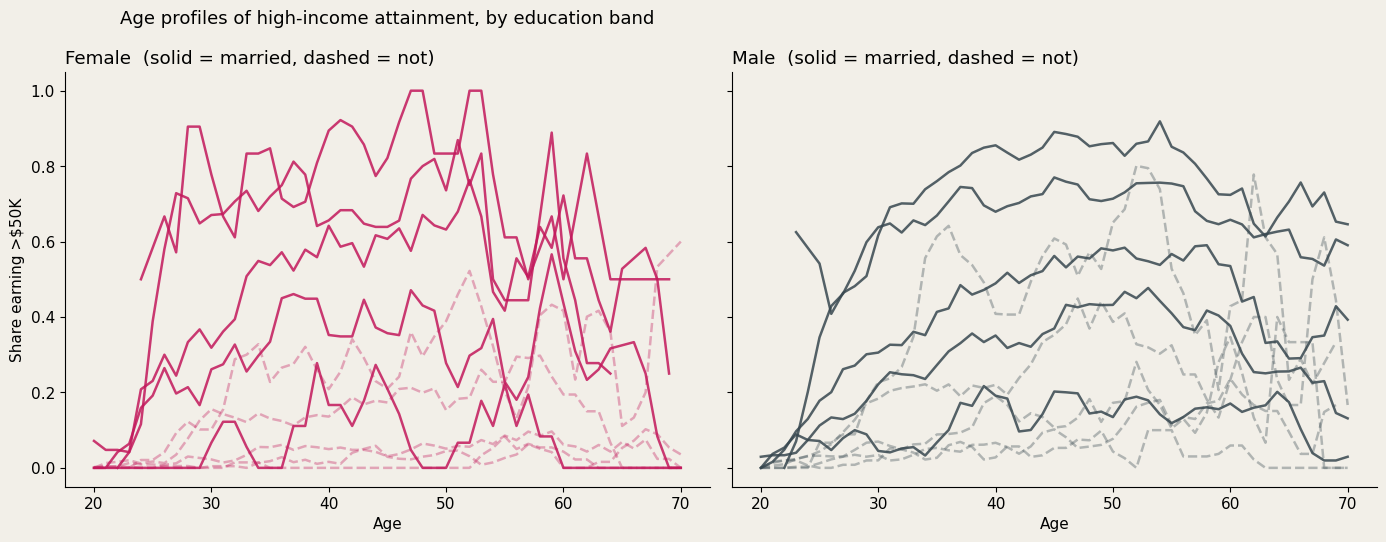

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

for ax, sx in zip(axes, ['Female', 'Male']):
    sub = g[g['sex'] == sx]
    for (ed, mr), s in sub.groupby(['edu_band', 'married']):
        ax.plot(s['age'], s['rate_s'], lw=1.8,
                color=FEMALE if sx == 'Female' else MALE,
                alpha=0.85 if mr == 'Mar' else 0.35,
                ls='-' if mr == 'Mar' else '--')
    ax.set_title(f'{sx}  (solid = married, dashed = not)', loc='left')
    ax.set_xlabel('Age')

axes[0].set_ylabel('Share earning >$50K')
plt.suptitle('Age profiles of high-income attainment, by education band',
             x=0.09, ha='left', size=13)
plt.tight_layout()
plt.savefig('age_profiles.png', dpi=110)
plt.show()

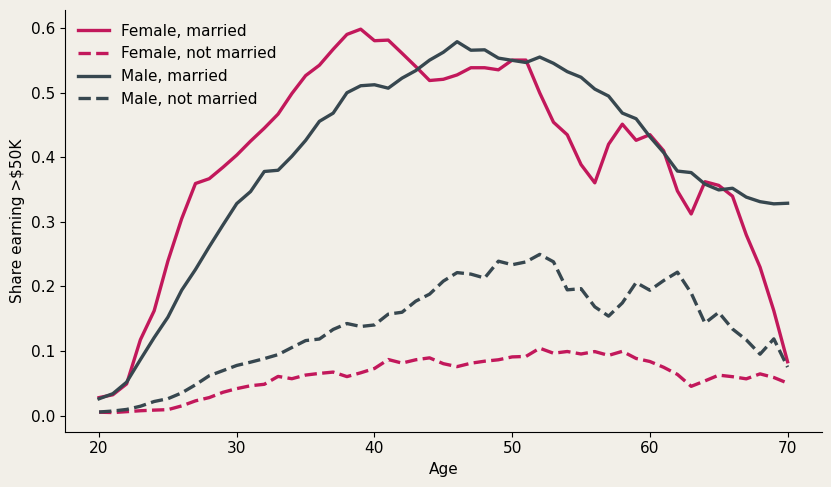

married_label  married  not married  ratio
sex                                       
Female          0.4574       0.0517   8.85
Male            0.4501       0.0937   4.80


In [6]:
prof = d.copy()
prof['married_label'] = np.where(prof['married'] == 'Mar', 'married', 'not married')

gm = (prof.groupby(['sex', 'married_label', 'age'])['high_income']
          .mean().reset_index(name='rate'))
gm['smoothed'] = (gm.groupby(['sex', 'married_label'])['rate']
                    .transform(lambda s: s.rolling(5, center=True,
                                                   min_periods=1).mean()))

fig, ax = plt.subplots(figsize=(8.45, 5))

for (sx, mr), sub in gm.groupby(['sex', 'married_label']):
    ax.plot(sub['age'], sub['smoothed'], lw=2.4,
            color=FEMALE if sx == 'Female' else MALE,
            ls='-' if mr == 'married' else '--',
            label=f'{sx}, {mr}')

ax.set_xlabel('Age')
ax.set_ylabel('Share earning >$50K')
ax.legend(frameon=False, fontsize=11, loc='upper left')

plt.tight_layout()
plt.savefig('age_profiles_means.png', dpi=130)
plt.show()

rates = prof.groupby(['sex', 'married_label'])['high_income'].mean().unstack()
rates['ratio'] = (rates['married'] / rates['not married']).round(2)
print(rates.round(4).to_string())

The profiles rise steeply through the thirties, plateau across the forties and
fifties, and soften after sixty. That is the smooth ordered shape a recurrent
model needs in order to have anything to forecast.

The sex gap runs through these curves as well, though not in the direction the
pooled figures suggest. Married men and married women reach almost the same rate
(45.0% and 45.7%), so the whole gap sits between the unmarried curves, where men
reach 9.4% and women 5.2%. Marriage therefore separates women's outcomes far more
sharply than men's, a ratio of 8.85 against 4.80.

## Model

### Windowing

Each training example is a window of 8 consecutive ages used to predict the rate
at the 9th. Every timestep carries five features: the rate itself, the age
normalised to roughly 0–1, and three static identifiers for sex, marital status,
and education band, repeated across the window so the network can tell which
series it is reading.

The split is by target age rather than at random. Windows whose target age is 59
or below are used for training, and windows targeting ages 60–70 are held out.
Splitting at random would let the model train on age 62 and be tested on age 61
within the same series, which leaks the answer, so forecasting the older end from
the younger end is the only honest test available here.

In [7]:
W = 8            # window length
SPLIT_AGE = 59   # target age <= 59 trains | > 59 is held out

sex_map = {'Female': 0, 'Male': 1}
mar_map = {'Unm': 0, 'Mar': 1}
edu_map = {'E1_no_hs': 0, 'E2_hs': 1, 'E3_some_col': 2,
           'E4_bachelors': 3, 'E5_advanced': 4}

Xtr, ytr, Xte, yte, meta_te = [], [], [], [], []

for (sx, ed, mr), sub in g.groupby(['sex', 'edu_band', 'married']):
    sub   = sub.sort_values('age')
    rates = sub['rate_s'].values
    ages  = sub['age'].values

    for i in range(len(sub) - W):
        seq = np.column_stack([
            rates[i:i+W],                    # the series itself
            (ages[i:i+W] - 20) / 50.0,       # age, scaled to roughly 0-1
            np.full(W, sex_map[sx]),         # static group identifiers
            np.full(W, mar_map[mr]),         # repeated at every timestep
            np.full(W, edu_map[ed] / 4.0),
        ])
        target, target_age = rates[i+W], ages[i+W]

        if target_age <= SPLIT_AGE:
            Xtr.append(seq); ytr.append(target)
        else:
            Xte.append(seq); yte.append(target)
            meta_te.append((sx, ed, mr, target_age))

Xtr, ytr = np.array(Xtr, 'float32'), np.array(ytr, 'float32')
Xte, yte = np.array(Xte, 'float32'), np.array(yte, 'float32')

print(f"Train windows: {Xtr.shape}   (target ages 28-{SPLIT_AGE})")
print(f"Test  windows: {Xte.shape}   (target ages {SPLIT_AGE+1}-70)")
print(f"Train target mean {ytr.mean():.3f}   Test target mean {yte.mean():.3f}")

Train windows: (620, 8, 5)   (target ages 28-59)
Test  windows: (191, 8, 5)   (target ages 60-70)
Train target mean 0.319   Test target mean 0.258


### Architectures

Four models are fitted on identical inputs. The first three are recurrent; the
fourth flattens the window and feeds it to a dense layer, which supplies the
comparison H3 requires.

| Model | Recurrent? | Notes |
|---|---|---|
| `SimpleRNN(32)` | Yes | The basic step function |
| `LSTM(32)` | Yes | Adds the carry track that guards against vanishing gradients |
| `GRU(32)` | Yes | Gated like LSTM, fewer parameters |
| `Dense(32)` on flattened input | **No** | Sees the same 8 values with order discarded |

All four use `mse` loss (regression), the Adam optimizer, and early stopping on a
validation split, so training halts when validation loss stops improving rather
than at a fixed epoch count.

In [8]:
def build(kind):
    inp = keras.Input(shape=(W, 5))
    if   kind == 'SimpleRNN': x = layers.SimpleRNN(32)(inp)
    elif kind == 'LSTM':      x = layers.LSTM(32)(inp)
    elif kind == 'GRU':       x = layers.GRU(32)(inp)
    else:                     x = layers.Dense(32, activation='relu')(
                                      layers.Flatten()(inp))
    out = layers.Dense(1)(x)                     # linear output: regression
    m = keras.Model(inp, out, name=kind.replace('(', '_').replace(')', ''))
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return m

build('SimpleRNN').summary()

Model: "SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 8, 5)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,249 (4.88 KB)

 Trainable params: 1,249 (4.88 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
os.makedirs('logs', exist_ok=True)

def r2(pred, true):
    return 1 - np.sum((pred - true)**2) / np.sum((true - true.mean())**2)

results, histories, preds = [], {}, {}

for kind in ['SimpleRNN', 'LSTM', 'GRU', 'Dense(flatten)']:
    # Reseed before each build so weight initialisation is identical across
    # runs. Without this the four models are compared under different random
    # draws and the ranking changes from one execution to the next.
    keras.utils.set_random_seed(42)
    model = build(kind)
    cbs = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=25,
                                      restore_best_weights=True),
        keras.callbacks.TensorBoard(log_dir=f'logs/{kind}'),
    ]
    h = model.fit(Xtr, ytr, validation_split=0.2, epochs=300,
                  batch_size=32, callbacks=cbs, verbose=0)

    p = model(Xte, training=False).numpy().ravel()
    results.append({
        'Model': kind,
        'Recurrent': 'yes' if kind != 'Dense(flatten)' else 'no',
        'MAE':  round(float(np.mean(np.abs(p - yte))), 4),
        'RMSE': round(float(np.sqrt(np.mean((p - yte)**2))), 4),
        'R2':   round(float(r2(p, yte)), 3),
        'Epochs': len(h.history['loss']),
    })
    histories[kind], preds[kind] = h, p
    print(f"  {kind:16s} done ({len(h.history['loss'])} epochs)", flush=True)

res = pd.DataFrame(results)
print("\nHeld-out performance (target ages 60-70)\n")
print(res.to_string(index=False))

  SimpleRNN        done (29 epochs)
  LSTM             done (30 epochs)
  GRU              done (116 epochs)
  Dense(flatten)   done (171 epochs)

Held-out performance (target ages 60-70)

         Model Recurrent    MAE   RMSE    R2  Epochs
     SimpleRNN       yes 0.1229 0.1489 0.583      29
          LSTM       yes 0.0960 0.1218 0.721      30
           GRU       yes 0.0686 0.0969 0.824     116
Dense(flatten)        no 0.0810 0.1033 0.799     171


## Baselines

Two baselines bracket the result. **Train mean** predicts the average rate for
every window and establishes the floor. **Persistence** repeats the last observed
value in the window, which on a smooth series is difficult to beat and is the
standard comparison for a forecasting problem. A model that cannot beat it has
learned nothing beyond the fact that adjacent ages resemble each other.

In [10]:
persistence = Xte[:, -1, 0]                       # last rate in the window
train_mean  = np.full(len(yte), ytr.mean())

base = []
for nm, p in [('Persistence', persistence), ('Train mean', train_mean)]:
    base.append({'Model': nm, 'Recurrent': '—',
                 'MAE':  round(float(np.mean(np.abs(p - yte))), 4),
                 'RMSE': round(float(np.sqrt(np.mean((p - yte)**2))), 4),
                 'R2':   round(float(r2(p, yte)), 3), 'Epochs': 0})

full = pd.concat([res, pd.DataFrame(base)], ignore_index=True)
print("All models and baselines\n")
print(full.to_string(index=False))

All models and baselines

         Model Recurrent    MAE   RMSE     R2  Epochs
     SimpleRNN       yes 0.1229 0.1489  0.583      29
          LSTM       yes 0.0960 0.1218  0.721      30
           GRU       yes 0.0686 0.0969  0.824     116
Dense(flatten)        no 0.0810 0.1033  0.799     171
   Persistence         — 0.0595 0.1007  0.809       0
    Train mean         — 0.2096 0.2385 -0.069       0


## Training curves and predictions

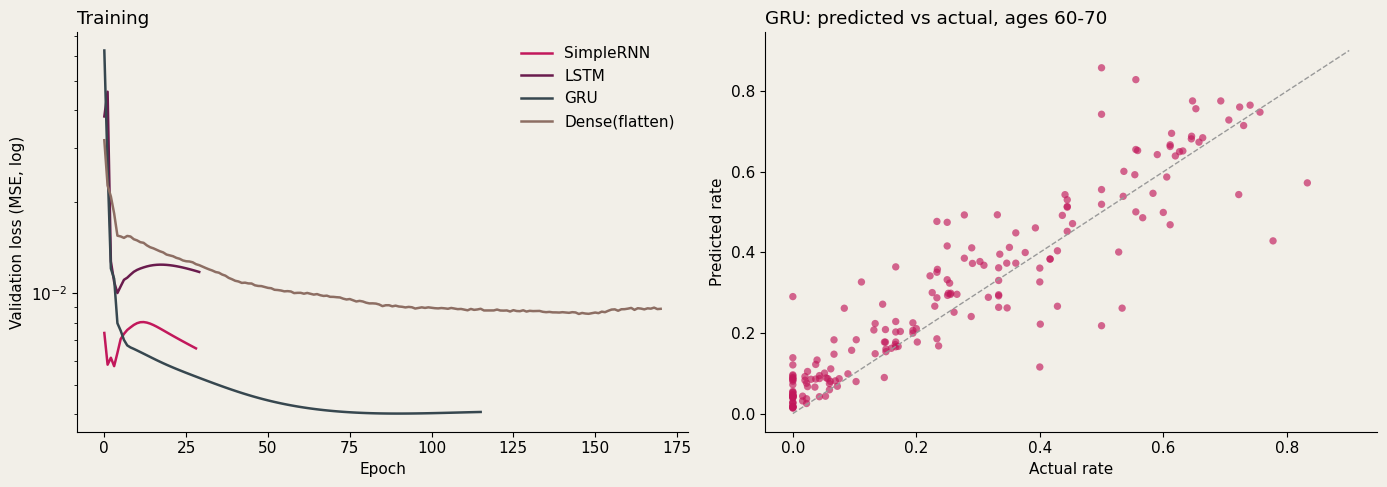

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for kind, col in zip(histories, [FEMALE, '#6A1B4D', MALE, '#8D6E63']):
    axes[0].plot(histories[kind].history['val_loss'], color=col, lw=1.8,
                 label=kind)
axes[0].set_yscale('log')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Validation loss (MSE, log)')
axes[0].set_title('Training', loc='left'); axes[0].legend(frameon=False)

best = res.loc[res['R2'].idxmax(), 'Model']
axes[1].scatter(yte, preds[best], s=28, color=FEMALE, alpha=0.65,
                edgecolor='none')
lims = [0, max(yte.max(), preds[best].max()) * 1.05]
axes[1].plot(lims, lims, color='#999999', ls='--', lw=1)
axes[1].set_xlabel('Actual rate'); axes[1].set_ylabel('Predicted rate')
axes[1].set_title(f'{best}: predicted vs actual, ages 60-70', loc='left')

plt.tight_layout()
plt.savefig('rnn_training.png', dpi=110)
plt.show()

In [12]:
# Where does the best model do badly? Errors by group.
err = pd.DataFrame(meta_te, columns=['sex', 'edu_band', 'married', 'age'])
err['actual'] = yte
err['pred']   = preds[best]
err['abs_err'] = (err['pred'] - err['actual']).abs()

print(f"{best} — mean absolute error by group\n")
print(err.groupby(['sex', 'married'])['abs_err'].agg(['mean', 'max'])
         .round(4).to_string())

GRU — mean absolute error by group

                  mean     max
sex    married                
Female Mar      0.1121  0.3582
       Unm      0.0486  0.2717
Male   Mar      0.0516  0.1621
       Unm      0.0805  0.3492


## Report

**Every network clears the floor.** Predicting the training mean returns R²
of −0.069, since the held-out ages 60–70 sit above the overall average and a
constant prediction is biased low across the whole test set. The four fitted
networks return R² between 0.583 and 0.824.

**GRU is the strongest model and SimpleRNN the weakest.** GRU reaches R² 0.824
and MAE 0.0686, LSTM 0.721, and SimpleRNN 0.583. The gated architectures both
beat the ungated one SimpleRNN also
stopped after 29 epochs against GRU's 116, so it was halted early by the
validation criterion rather than converging.

**Recurrence beat flattening, but only for the gated models.** GRU's 0.824
exceeds the flattened dense model's 0.799 on identical inputs, so order does
carry usable information. SimpleRNN at 0.583 falls well below it, which means the
advantage belongs to the gating rather than to recurrence by itself.

**Persistence remains competitive with every model.** Repeating the last observed
rate returns R² 0.809 and MAE 0.0595, better than three of the four networks on
R² and better than all four on MAE. Only GRU exceeds it, and only on R². After
smoothing over three ages the rate at 61 closely resembles the rate at 60, so a
rule with no parameters captures most of the available signal.

**Errors concentrate among married women.** Mean absolute error under GRU is
0.112 for that group against 0.049 for unmarried women, 0.052 for married men,
and 0.081 for unmarried men.

## Assessing H3

**Learnable sequential structure: supported.** All four networks recover the age
profile on held-out ages at R² 0.583–0.824 against a naive floor of −0.069, so
the series carry structure a model can fit and generalise from.

**Recurrence outperforming flattening: partially supported.** GRU beats the
flattened dense model (0.824 against 0.799) on identical inputs, but LSTM and
SimpleRNN both fall below it. The hypothesis holds for the best recurrent
architecture rather than for recurrence as a class.

**The comparison is fragile, and that is itself a finding.** Before the random seed was fixed for each model separately, produced
two different orderings, one with SimpleRNN highest at 0.852 and Dense at 0.734,
another with Dense highest at 0.801 and SimpleRNN at 0.779. With 620 training
windows the weight initialisation moves the results by more than the gaps between
architectures. The training loop now reseeds before each build so the four models
are compared under the same random draw and reproduces exactly, but
that fixes the comparison rather than making any single ordering.

**The defensible reading is that these models are not clearly earning their
complexity.** A zero-parameter persistence rule beats three of the four networks
on R² and all four on MAE, and the architecture ranking is unstable across seeds.
That reflects the data rather than a failure of method: 20 smoothed series of 51
points each is not the regime these architectures were built for.

## Techniques used and why

**Aggregation into sequences.** The dataset contains no sequence, so age supplied
an ordering at regular one-year intervals. Grouping by sex × education band ×
marital status yields 20 parallel series of roughly 51 ages each, and windowing
at length 8 produces 811 examples. Coarser grouping would have given fewer and
longer series, while the finer (occupation × sex) grouping tried first left cells
too thin to estimate a stable rate.

**Rolling smoothing.** With a median cell of 17 people, a raw rate shifts by
about 0.06 when a single person crosses the threshold. A 3-age centred mean damps
that sampling noise, and it is applied to the series rather than to the
definition of the outcome.

**`SimpleRNN`.** Implements the step function where the output at step t is an activation of the input at t combined with
the state carried from t−1. It is the simplest architecture that qualifies as
recurrent, which makes it the natural starting point.

**`LSTM`.** Adds the carry track of Hochreiter and Schmidhuber (1997) so that
information can bypass many timesteps intact. It was included to test whether
long-range memory helps, and at a window of 8 timesteps it does not.

**`GRU`.** Gated in the same way as LSTM but with fewer parameters, included as
the middle point between the two recurrent extremes.

**Flattened `Dense`.** Not recurrent, so it supplies the
control that turns the recurrence claim into something testable rather than
assumed.

**Early stopping.** With 620 training windows and several thousand parameters,
overfitting is the binding risk, so training halts once validation loss stops
improving and the best weights are restored.

**TensorBoard.** Logs are written per model so the training curves can be
inspected interactively with `%tensorboard --logdir logs`.

## Limitations

**Age-ordered, not time-ordered.** The series are cross-sectional age profiles
rather than cohorts, so the 65-year-olds and the 30-year-olds are different
people observed in 1994 rather than the same people followed for 35 years, and
age, period, and cohort effects are fully confounded. Forecasting age 62 from
ages 54–61 predicts an unobserved slice of one 1994 population from observed
slices, and says nothing about anyone's future earnings.

**Aggregation discards the individual.** Modeling group rates rather than people
removes the person-level features that carried Project 3, including occupation,
hours, and capital gains, so this project answers a narrower question than its
predecessors.

**Smoothing is a modeling choice.** The 3-age rolling mean makes the series
learnable but also makes them smoother, which flatters the networks and the
persistence baseline alike. An unsmoothed run would lower every R² reported here.

**Thin cells at the extremes.** Some group-age cells hold very few people even
after grouping coarsely, particularly for women in the advanced-degree bands at
older ages, and the rates in those cells are unstable.

**No architecture search.** Hidden width 32, window length 8, and batch size 32
are defensible defaults rather than tuned values, and window length in particular
is a substantive choice that would move the results.

**Single seed per architecture.** The training loop reseeds before each model. Ituns under other
seeds produced different orderings, so the gaps between architectures reported
here are smaller than the run-to-run variation and should not be read as a stable
ranking.

## Act

**What the analysis supports.** The age profile of high-income attainment carries
real structure, since all four networks fit it well above the naive floor and the
best of them exceeds a persistence rule. The demographic patterns established in
the earlier projects reappear in the shape of these curves, with marriage
separating women's outcomes far more sharply than men's (a ratio of 8.85 against
4.80), and the largest model errors falling on married women.

**What it does not support.** No general claim that recurrence helps, since only
the gated GRU beat the flattened model and the ordering shifts with the random
seed. No forecast about any individual, since the sequences are cross-sectional
age profiles rather than people followed over time. And no claim that deep
learning is the right tool at this scale, given how close a parameter-free
baseline stays to the best network.

**What would change the answer.** The binding constraint is that this dataset has
no time dimension, so the sequence had to be constructed from age.

In [13]:
#Janna Hoyne